Loaded scope data from scope_async.csv
Scope samples: 6400
Detected 3 nominal runs in adc_async_nominal.txt
Detected 3 aliased runs in adc_async_alias.txt

Async Nominal Sampling (200 Hz)
-------------------------------
Run 1: estimated sampled frequency = 10.00 Hz


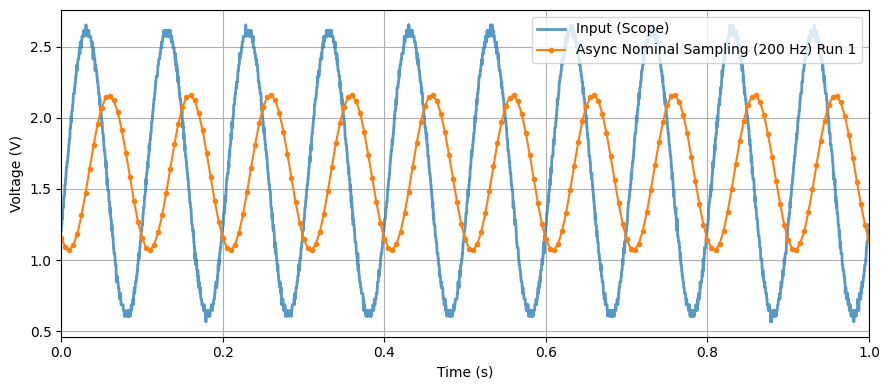

Run 2: estimated sampled frequency = 10.00 Hz


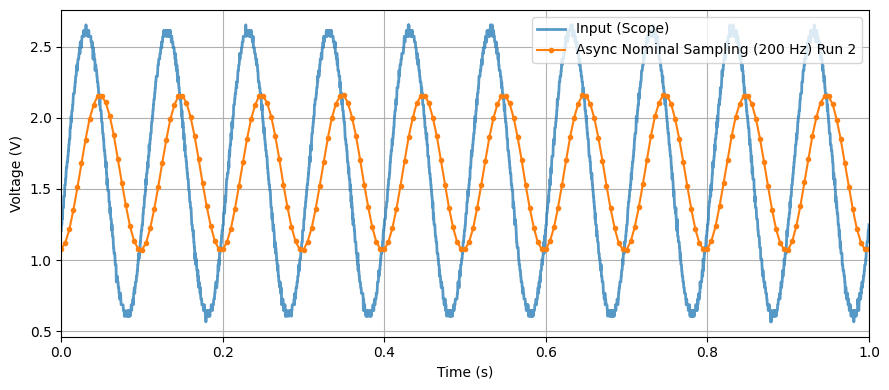

Run 3: estimated sampled frequency = 10.00 Hz


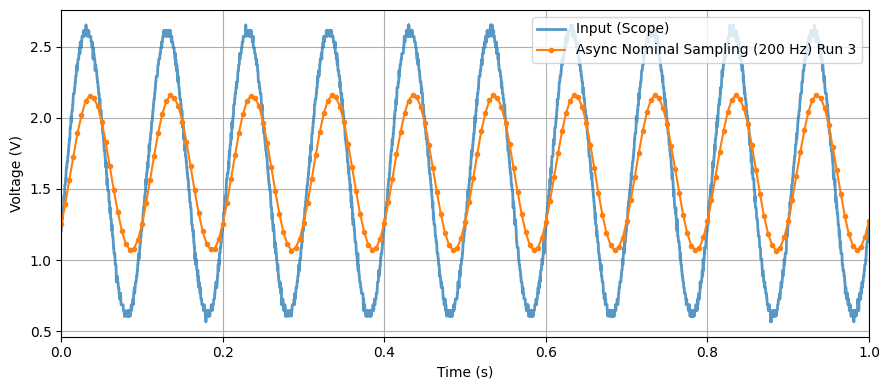


Async Aliased Sampling (5 Hz)
-----------------------------
Run 1: estimated sampled frequency = 0.50 Hz


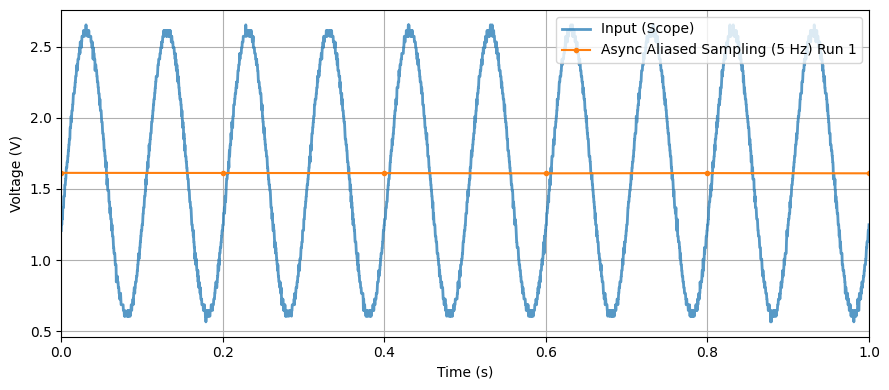

Run 2: estimated sampled frequency = 1.50 Hz


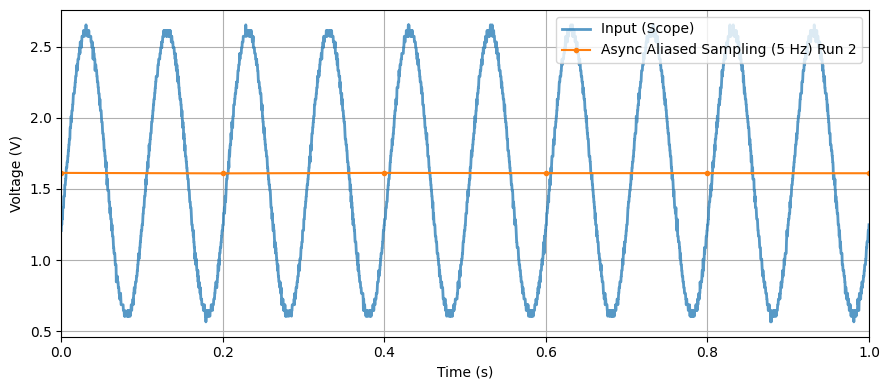

Run 3: estimated sampled frequency = 0.50 Hz


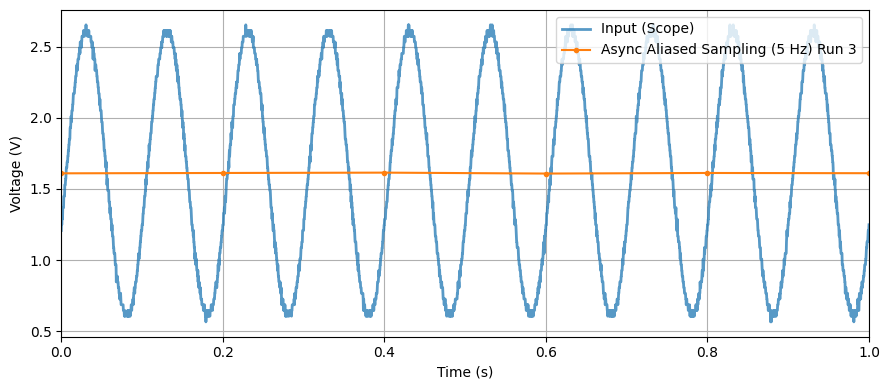


Summary
-------
Async nominal (200 Hz): mean = 10.00 Hz, 95% CI = [10.00, 10.00] Hz
Async aliased (5 Hz): mean = 0.83 Hz, 95% CI = [-0.60, 2.27] Hz


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bme554 import read_hex_data, unwrap_twos_complement

# ============================================================
# User-set constants
# ============================================================
SAMPLES_NOMINAL = 400
SAMPLES_ALIAS = 10
VREF = 3.3
RESOLUTION = 4096

NOMINAL_FS = 200.0
ALIASED_FS = 5.0

SCOPE_FILE = "scope_async.csv"
NOMINAL_FILE = "adc_async_nominal.txt"
ALIASED_FILE = "adc_async_alias.txt"

TMAX_PLOT = 1   # adjust if needed for your signal view

# ============================================================
# Helper functions
# ============================================================
def estimate_freq_fft(signal, fs):
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)

    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(N, d=1/fs)

    if len(fft_vals) <= 1:
        return np.nan

    idx = np.argmax(np.abs(fft_vals[1:])) + 1
    return fft_freqs[idx]

def split_hex_runs(filename, samples_per_run):
    hex_data = read_hex_data(filename)
    bytes_per_run = 2 * samples_per_run

    runs = []
    for i in range(0, len(hex_data), bytes_per_run):
        chunk = hex_data[i:i + bytes_per_run]
        if len(chunk) == bytes_per_run:
            runs.append(chunk)

    return runs

def decode_run(run_chunk, vref, resolution):
    adc_vals = np.array(unwrap_twos_complement(run_chunk), dtype=float)
    return (adc_vals / resolution) * vref

def load_scope_csv(scope_file):
    """
    Loader for the new 2-column scope CSV format:
    row 0: x-axis, 2
    row 1: second, Volt
    row 2+: time, voltage
    """
    df = pd.read_csv(scope_file, header=None, skiprows=2)

    t_scope = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    v_scope = pd.to_numeric(df.iloc[:, 1], errors="coerce")

    valid = t_scope.notna() & v_scope.notna()
    t_scope = t_scope[valid].to_numpy(dtype=float)
    v_scope = v_scope[valid].to_numpy(dtype=float)

    t_scope = t_scope - t_scope[0]
    return t_scope, v_scope

def match_offset(t_ref, y_ref, t_sig, y_sig, tmax):
    ref_mask = t_ref <= tmax
    sig_mask = t_sig <= tmax

    if not np.any(ref_mask) or not np.any(sig_mask):
        return y_sig

    ref_mean = np.mean(y_ref[ref_mask])
    sig_mean = np.mean(y_sig[sig_mask])

    return y_sig + (ref_mean - sig_mean)

def plot_runs(runs, fs, case_name, t_scope, v_scope):
    print(f"\n{case_name}")
    print("-" * len(case_name))

    scope_mask = t_scope <= TMAX_PLOT
    t_scope_plot = t_scope[scope_mask]
    v_scope_plot = v_scope[scope_mask]

    run_freqs = []

    for i, run in enumerate(runs, start=1):
        adc_voltage = decode_run(run, VREF, RESOLUTION)
        t_adc = np.arange(len(adc_voltage)) / fs

        freq = estimate_freq_fft(adc_voltage, fs)
        run_freqs.append(freq)
        print(f"Run {i}: estimated sampled frequency = {freq:.2f} Hz")

        adc_voltage_aligned = match_offset(
            t_scope_plot, v_scope_plot, t_adc, adc_voltage, TMAX_PLOT
        )

        adc_mask = t_adc <= TMAX_PLOT
        t_adc_plot = t_adc[adc_mask]
        adc_plot = adc_voltage_aligned[adc_mask]

        plt.figure(figsize=(9, 4))
        plt.plot(t_scope_plot, v_scope_plot, label="Input (Scope)", linewidth=2, alpha=0.75)
        plt.plot(t_adc_plot, adc_plot, "o-", label=f"{case_name} Run {i}", markersize=3)
        plt.xlim(0, TMAX_PLOT)
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

    return np.array(run_freqs, dtype=float)

def mean_ci_95(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    if n == 0:
        return np.nan, np.nan
    if n == 1:
        return np.mean(x), 0.0

    mean = np.mean(x)
    sd = np.std(x, ddof=1)
    sem = sd / np.sqrt(n)

    # t critical for 95% CI, df = n-1
    from scipy import stats
    tcrit = stats.t.ppf(0.975, df=n-1)
    ci = tcrit * sem
    return mean, ci

# ============================================================
# Load scope data
# ============================================================
t_scope, v_scope = load_scope_csv(SCOPE_FILE)
print(f"Loaded scope data from {SCOPE_FILE}")
print(f"Scope samples: {len(t_scope)}")

# ============================================================
# Load and split async ADC data
# ============================================================
nominal_runs = split_hex_runs(NOMINAL_FILE, SAMPLES_NOMINAL)
aliased_runs = split_hex_runs(ALIASED_FILE, SAMPLES_ALIAS)

print(f"Detected {len(nominal_runs)} nominal runs in {NOMINAL_FILE}")
print(f"Detected {len(aliased_runs)} aliased runs in {ALIASED_FILE}")

# ============================================================
# Plot all 6 runs
# ============================================================
nominal_freqs = plot_runs(nominal_runs, NOMINAL_FS, "Async Nominal Sampling (200 Hz)", t_scope, v_scope)
aliased_freqs = plot_runs(aliased_runs, ALIASED_FS, "Async Aliased Sampling (5 Hz)", t_scope, v_scope)

# ============================================================
# Summary statistics
# ============================================================
nom_mean, nom_ci = mean_ci_95(nominal_freqs)
ali_mean, ali_ci = mean_ci_95(aliased_freqs)

print("\nSummary")
print("-------")
print(f"Async nominal (200 Hz): mean = {nom_mean:.2f} Hz, 95% CI = [{nom_mean - nom_ci:.2f}, {nom_mean + nom_ci:.2f}] Hz")
print(f"Async aliased (5 Hz): mean = {ali_mean:.2f} Hz, 95% CI = [{ali_mean - ali_ci:.2f}, {ali_mean + ali_ci:.2f}] Hz")